In [40]:
# ===========================================================
# Cell 1: Import required Python modules
# ===========================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd


In [41]:
# ===========================================================
# Cell 2: Generate synthetic LIG dataset
# ===========================================================
rng = np.random.default_rng(0)  # Random number generator
n_samples = 100  # Number of samples

# Laser fluence (J/cm²)
fluence = rng.uniform(1.5, 3.5, size=n_samples)

# Raman ID/IG defect ratio (decreases with higher fluence)
ID_IG = 1.2 - 0.2 * fluence + rng.normal(0, 0.05, size=n_samples)

# Sheet resistance Rs (Ω/sq) increases with defect ratio
Rs = 60 * ID_IG + rng.normal(0, 5, size=n_samples)

# Stack into feature matrix: rows = samples, columns = features
X = np.vstack((fluence, ID_IG, Rs)).T


In [42]:
# ===========================================================
# Cell 3: Compute covariance matrix
# ===========================================================
# Center the data (subtract mean)
X_centered = X - np.mean(X, axis=0)

# Sample covariance matrix
cov_matrix = 1 / (n_samples - 1) * (X_centered.T @ X_centered)
print("Covariance matrix:")
print(cov_matrix)


Covariance matrix:
[[ 3.71187638e-01 -7.54506150e-02 -4.75858307e+00]
 [-7.54506150e-02  1.77105724e-02  1.11307853e+00]
 [-4.75858307e+00  1.11307853e+00  1.00841294e+02]]


In [43]:
# ===========================================================
# Cell 4: Compute correlation matrix
# ===========================================================
# Standard deviations
std_dev = np.std(X, axis=0, ddof=1)

# Correlation matrix
corr_matrix = cov_matrix / np.outer(std_dev, std_dev)
print("\nCorrelation matrix:")
print(corr_matrix)



Correlation matrix:
[[ 1.         -0.93057147 -0.77778882]
 [-0.93057147  1.          0.83289509]
 [-0.77778882  0.83289509  1.        ]]


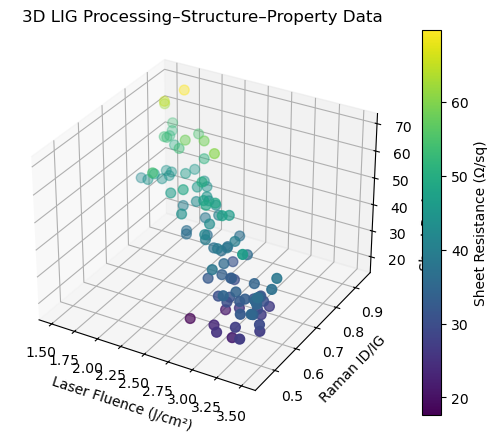

In [44]:
# ===========================================================
# Cell 5: Visualize data in 3D scatter plot
# ===========================================================
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot colored by Rs
scatter = ax.scatter(fluence, ID_IG, Rs, c=Rs, cmap='viridis', s=50)
ax.set_xlabel('Laser Fluence (J/cm²)')
ax.set_ylabel('Raman ID/IG')
ax.set_zlabel('Sheet Resistance (Ω/sq)')
ax.set_title('3D LIG Processing–Structure–Property Data')
fig.colorbar(scatter, ax=ax, label='Sheet Resistance (Ω/sq)')
plt.show()
